In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Model by Season Ranks

### Gathering Data

##### Creating a Ranked Data Frame

In [2]:
df = pd.read_csv('data/all_team_data_trimmed.csv')
df['Season'] = df['Season'].astype(str)
# df.dropna()
df.head()

,Team,Season,Wins,Losses,O_Pts/G,O_RYds/G,O_PYds/G,O_1downs_Tot,O_3down_Pct,rush_att,...,D_1downs_Tot,D_3down_Pct,def_int,def_int_td,sacks,fumbles_rec,fumbles_rec_td,blocked_kick,safety,total_ret_td
0,ARI,2021,11,6,26.4,122.1,251.5,367,45.2,514,...,336,38.2,13.0,1.0,41.0,14.0,1.0,0.0,0.0,0.0
1,ATL,2021,7,10,18.4,85.4,218.4,306,38.9,393,...,383,48.4,12.0,2.0,17.0,8.0,0.0,1.0,0.0,0.0
2,BAL,2021,8,9,22.8,145.8,233.0,394,36.4,517,...,340,34.8,9.0,1.0,33.0,6.0,1.0,1.0,0.0,0.0
3,BUF,2021,11,6,28.4,129.9,252.0,398,46.4,514,...,285,30.8,21.0,1.0,46.0,9.0,0.0,2.0,0.0,0.0
4,CAR,2021,5,12,17.9,108.4,190.5,322,35.7,455,...,311,37.8,9.0,0.0,39.0,6.0,0.0,0.0,0.0,0.0


In [3]:
# making a mask to set the sort directions for each column
# this makes teams with lower defensive yards/points allowed ranked at the top, while
# teams with high offensive yards/points are ranked at the top as well 
# top = 1

# mask_dir = [False, False, False, True, False, False, False, False, False, False, False, False, False, \
#             True, True, True, True, True, True, True,  True, True, True,\
#             False, False, False, False, False, False, False, False]

mask_dir = [True, True, True, True, True, True, True, True, True, \
            False, False, False, False, False, False, False,  False, False, False,\
            True, True, True, True, True, True, True, True, True, True]

In [ ]:
# rank stats as categories (1-32)
ranked_years = []
for y in np.unique(df.Season): 
    y_df = df[df['Season']==y].copy()
    y_teams = y_df[['Team','Season', 'Wins', 'Losses']].copy()
    
    # updating columns one by one
    for i,col in enumerate(y_df.columns[4:]):
        y_rank = y_df[col].rank(method='min', ascending=mask_dir[i])
        y_df[col] = y_rank.dropna().astype('category')
    ranked_years.append(y_df)

# re-create dataframe
ranks = pd.concat(ranked_years)
ranks = ranks[df.columns]
ranks.to_csv('data/all_teams_ranked_trimmed.csv')

ranks.head()        

,Team,Season,Wins,Losses,O_Pts/G,O_RYds/G,O_PYds/G,O_1downs_Tot,O_3down_Pct,rush_att,...,D_1downs_Tot,D_3down_Pct,def_int,def_int_td,sacks,fumbles_rec,fumbles_rec_td,blocked_kick,safety,total_ret_td
64,ARI,2019,5,10,16.0,23.0,9.0,32.0,21.0,13.0,...,1.0,3.0,1.0,1.0,14.0,14.0,1.0,1.0,1.0,1.0
65,ATL,2019,7,9,20.0,3.0,30.0,30.0,22.0,3.0,...,15.0,11.0,11.0,11.0,2.0,3.0,12.0,1.0,1.0,20.0
66,BAL,2019,14,2,32.0,32.0,6.0,31.0,30.0,32.0,...,31.0,21.0,15.0,22.0,11.0,25.0,30.0,1.0,1.0,1.0
67,BUF,2019,10,6,9.0,25.0,7.0,11.0,9.0,27.0,...,27.0,26.0,20.0,1.0,25.0,18.0,1.0,1.0,23.0,20.0
68,CAR,2019,5,11,13.0,19.0,13.0,17.0,4.0,8.0,...,4.0,11.0,20.0,1.0,26.0,8.0,12.0,26.0,29.0,1.0


In [11]:
ranks.columns[4]

'O_Pts/G'

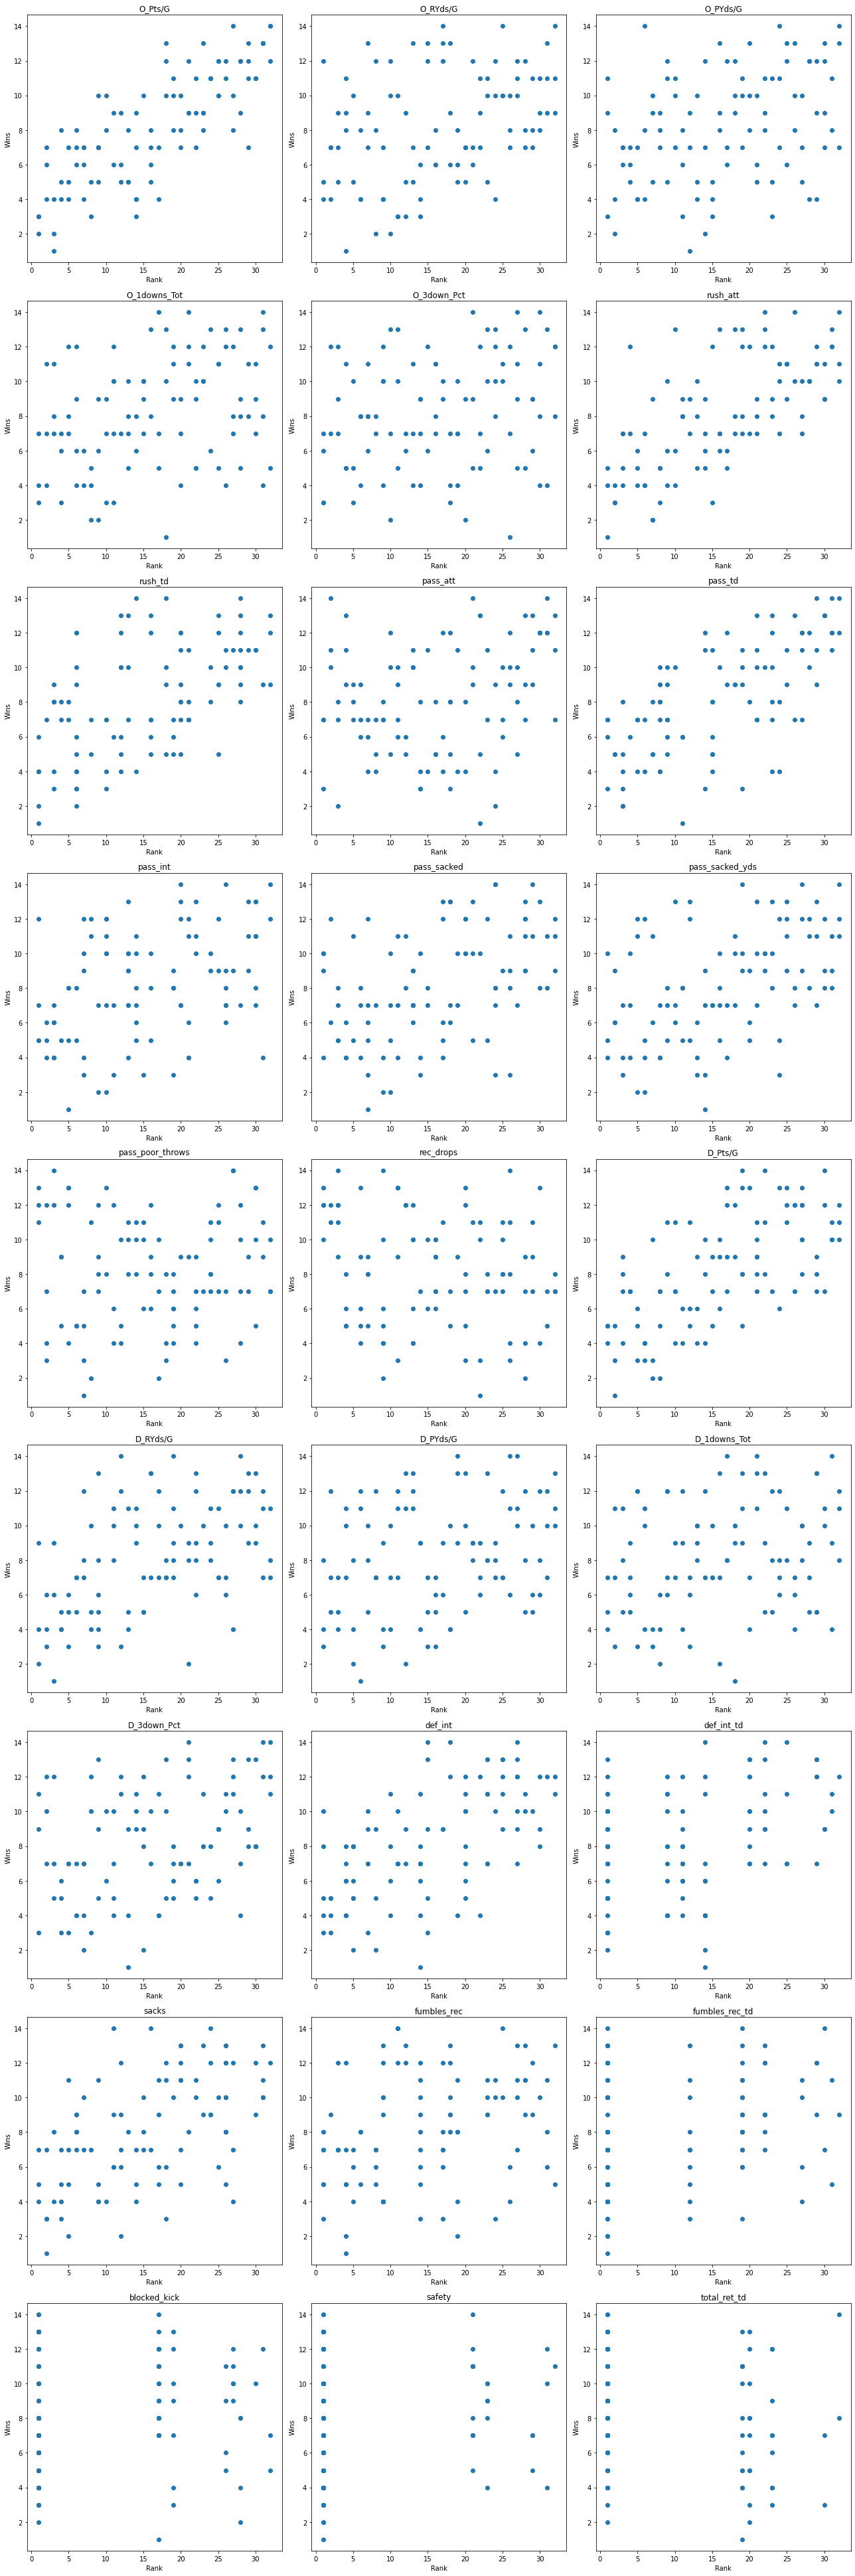

In [17]:
# plotting wins for each column
fig, ax = plt.subplots(9,3,figsize=(18,54))
col_idx = 4
data = ranks[4:]
for c in range(9): 
    for r in range(3):
        col = ranks.columns[col_idx]
        ax[c,r].scatter(ranks[col], ranks['Wins'])
        ax[c,r].set_title(col)
        ax[c,r].set_xlabel('Rank')
        ax[c,r].set_ylabel('Wins')
        col_idx += 1

plt.tight_layout()
plt.show()

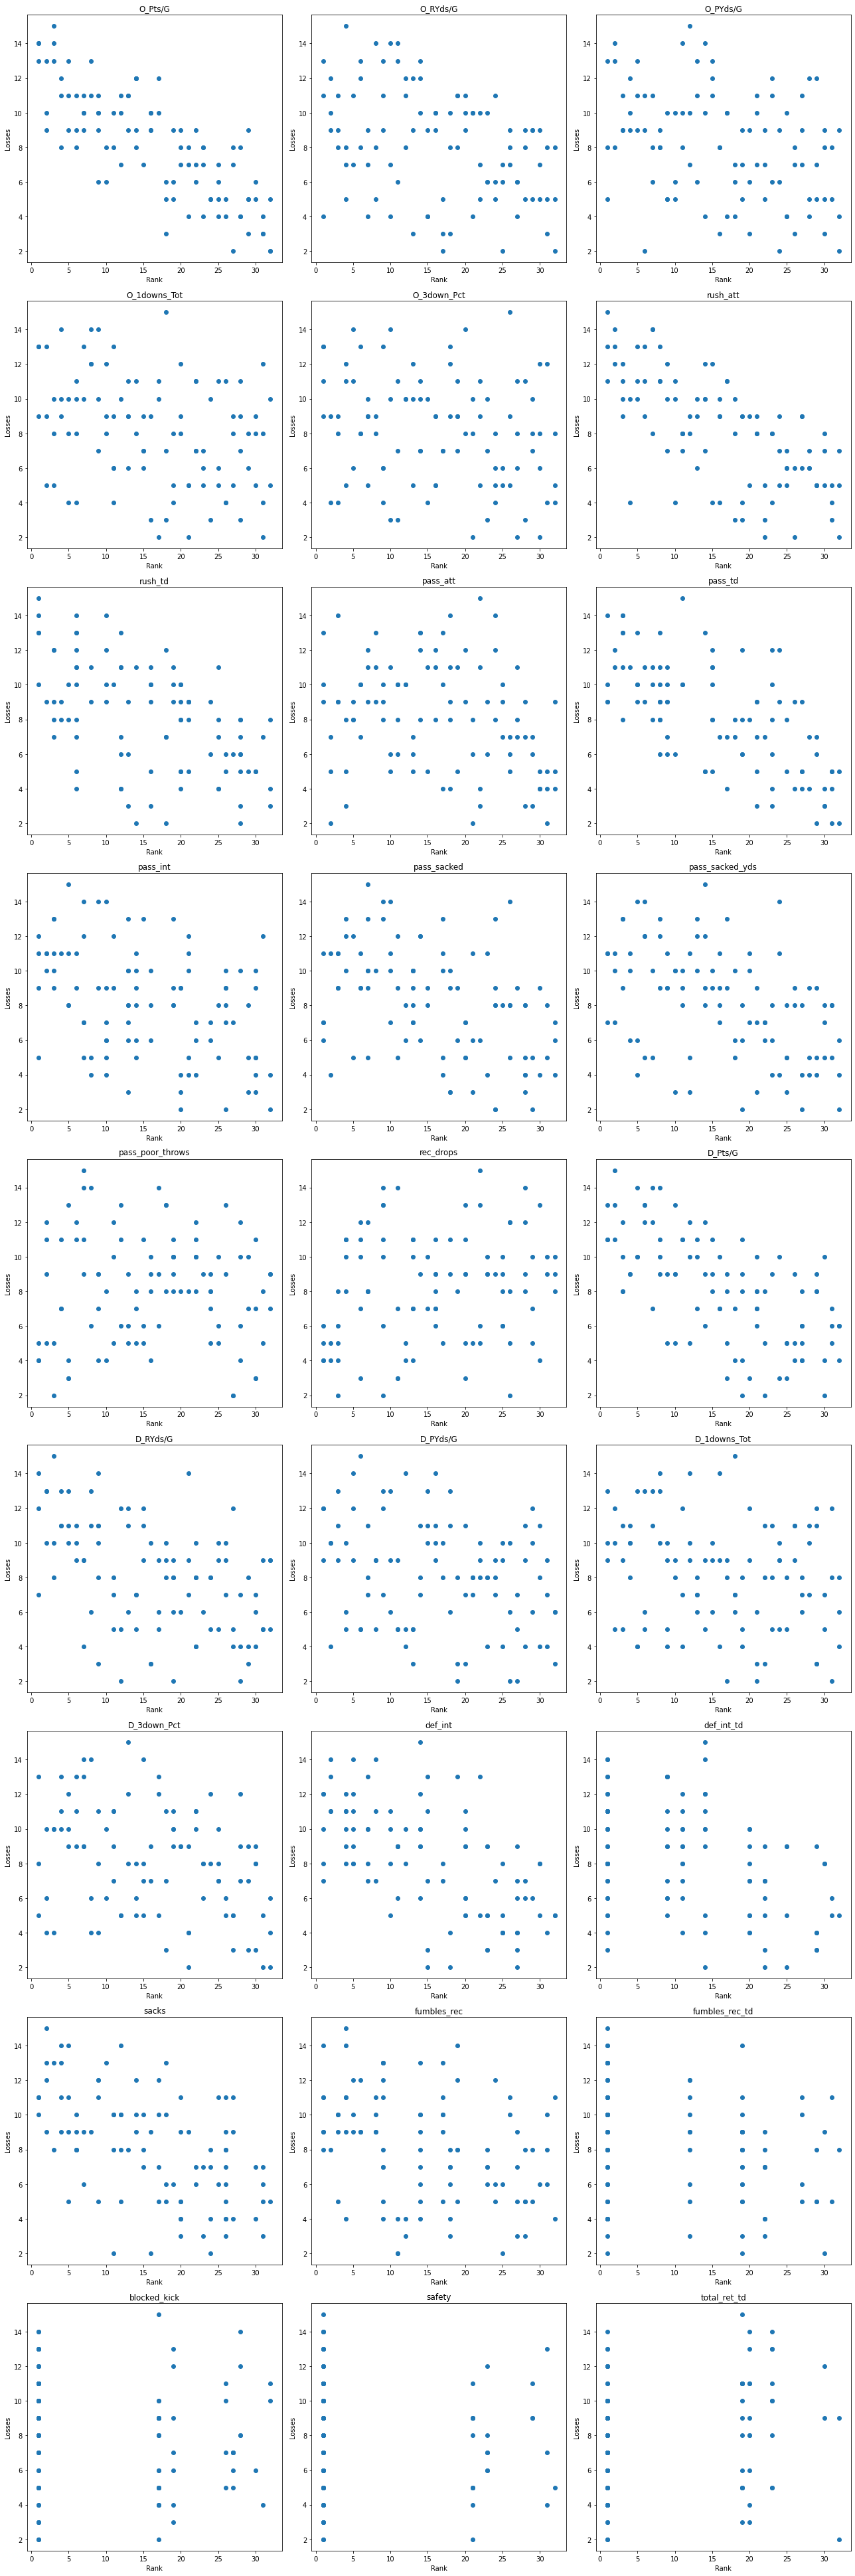

In [19]:
# plotting losses for each column
fig, ax = plt.subplots(9,3,figsize=(18,54))
col_idx = 4
data = ranks[4:]
for c in range(9): 
    for r in range(3):
        col = ranks.columns[col_idx]
        ax[c,r].scatter(ranks[col], ranks['Losses'])
        ax[c,r].set_title(col)
        ax[c,r].set_xlabel('Rank')
        ax[c,r].set_ylabel('Losses')
        col_idx += 1

plt.tight_layout()
plt.show()